# Proyek Klasifikasi Gambar: Buah
- **Nama:** Annisa Yusri Nur Rochmah
- **Email:** annisayusri59@gmail.com
- **ID Dicoding:** yusriannisa22

## Import Semua Packages/Library yang Digunakan

In [2]:
!pip install split-folders tensorflowjs -q

import os
import zipfile
import splitfolders
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
)
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np
from google.colab import files
from tensorflow.keras.preprocessing import image
import pathlib

plt.style.use('dark_background')
print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.19.0


## Data  Preparation

### Data Loading

In [3]:
from google.colab import files
files.upload()  # upload kaggle.json

import os
import zipfile

for file in os.listdir():
    if file.startswith('kaggle'):
        os.rename(file, 'kaggle.json')

os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

!kaggle datasets download -d moltean/fruits

local_zip = 'fruits.zip'

with zipfile.ZipFile(local_zip, 'r') as zip_ref:
    zip_ref.extractall('/content/sample_data')

base_dir = '/content/sample_data/fruits-360_100x100/fruits-360/Training'

classes = os.listdir(base_dir)
total_images = sum([len(os.listdir(os.path.join(base_dir, c))) for c in classes])

print(f"Jumlah kelas  : {len(classes)}")
print(f"Total gambar  : {total_images}")
print(f"Contoh kelas  : {classes[:10]}")

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/moltean/fruits
License(s): CC-BY-SA-4.0
100% 5.99G/5.99G [05:55<00:00, 18.1MB/s]

Jumlah kelas  : 260
Total gambar  : 137221
Contoh kelas  : ['Tomato 10', 'Pitahaya Red 1', 'Apple Red 1', 'Peach 1', 'Apple 7', 'Apple Granny Smith 1', 'Banana 1', 'Pepper Red 5', 'Cucumber 10', 'Cherry Wax Red 3']


## Data Preprocessing

### Split Dataset

In [4]:
splitfolders.ratio(
    base_dir,
    output="/content/dataset_final",
    seed=42,
    ratio=(0.8, 0.1, 0.1)  # 80% train, 10% val, 10% test
)

train_dir = '/content/dataset_final/train'
val_dir   = '/content/dataset_final/val'
test_dir  = '/content/dataset_final/test'

# Verifikasi jumlah file per split
for split_name, split_dir in [('Train', train_dir), ('Val', val_dir), ('Test', test_dir)]:
    count = sum([len(files_) for _, _, files_ in os.walk(split_dir)])
    print(f"{split_name:6s}: {count} gambar")

Copying files: 137221 files [01:08, 1999.49 files/s]


Train : 109690 gambar
Val   : 13635 gambar
Test  : 13896 gambar


## Modeling

In [5]:
IMG_SIZE   = (100, 100)
BATCH_SIZE = 32

# ── Augmentasi agresif untuk training ──────────────────────────
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

# ── Validation & Test: hanya rescale ───────────────────────────
test_val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

validation_generator = test_val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = test_val_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

NUM_CLASSES = train_generator.num_classes
print(f"\nJumlah kelas: {NUM_CLASSES}")
print(f"Class indices: {train_generator.class_indices}")

Found 109690 images belonging to 260 classes.
Found 13635 images belonging to 260 classes.
Found 13896 images belonging to 260 classes.

Jumlah kelas: 260
Class indices: {'Almonds 1': 0, 'Apple 10': 1, 'Apple 11': 2, 'Apple 12': 3, 'Apple 13': 4, 'Apple 14': 5, 'Apple 17': 6, 'Apple 18': 7, 'Apple 19': 8, 'Apple 20': 9, 'Apple 21': 10, 'Apple 22': 11, 'Apple 23': 12, 'Apple 5': 13, 'Apple 6': 14, 'Apple 7': 15, 'Apple 8': 16, 'Apple 9': 17, 'Apple Braeburn 1': 18, 'Apple Crimson Snow 1': 19, 'Apple Golden 1': 20, 'Apple Golden 2': 21, 'Apple Golden 3': 22, 'Apple Granny Smith 1': 23, 'Apple Pink Lady 1': 24, 'Apple Red 1': 25, 'Apple Red 2': 26, 'Apple Red 3': 27, 'Apple Red Delicious 1': 28, 'Apple Red Yellow 1': 29, 'Apple Red Yellow 2': 30, 'Apricot 1': 31, 'Avocado 1': 32, 'Avocado 2': 33, 'Avocado Black 1': 34, 'Avocado Black 2': 35, 'Avocado Green 1': 36, 'Banana 1': 37, 'Banana 3': 38, 'Banana 4': 39, 'Banana Lady Finger 1': 40, 'Banana Red 1': 41, 'Bean pod 1': 42, 'Beetroot 1'

In [6]:
def build_model(num_classes, img_size=(100, 100)):
    model = Sequential([
        # ── Block 1 ────────────────────────────────────
        Conv2D(32, (3,3), activation='relu', padding='same',
               input_shape=(img_size[0], img_size[1], 3)),
        BatchNormalization(),
        Conv2D(32, (3,3), activation='relu', padding='same'),
        MaxPooling2D(2, 2),
        Dropout(0.25),

        # ── Block 2 ────────────────────────────────────
        Conv2D(64, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3,3), activation='relu', padding='same'),
        MaxPooling2D(2, 2),
        Dropout(0.25),

        # ── Block 3 ────────────────────────────────────
        Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3,3), activation='relu', padding='same'),
        MaxPooling2D(2, 2),
        Dropout(0.25),

        # ── Block 4 ────────────────────────────────────
        Conv2D(256, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Dropout(0.25),

        # ── Classifier Head ───────────────────────────
        Flatten(),
        Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.0001)),
        BatchNormalization(),
        Dropout(0.5),
        Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.0001)),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    return model

model = build_model(NUM_CLASSES, IMG_SIZE)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 100, 100, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 100, 100, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 100, 100, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 50, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 50, 50, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 50, 50, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 25, 25, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 25, 25, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 25, 25, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     4,719,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 5,503,396 (20.99 MB)

 Trainable params: 5,501,412 (20.99 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [7]:
# ── 1. Custom Callback: stop saat target 95% tercapai ──────────
class StopAt95(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        train_acc = logs.get('accuracy', 0)
        val_acc   = logs.get('val_accuracy', 0)
        if train_acc >= 0.95 and val_acc >= 0.95:
            print(f"\n✅ Target 95% tercapai pada epoch {epoch+1}! "
                  f"Train: {train_acc:.4f} | Val: {val_acc:.4f}")
            self.model.stop_training = True

# ── 2. Reduce LR on Plateau ────────────────────────────────────
reduce_lr = ReduceLROnPlateau(
    monitor='val_accuracy',
    patience=3,
    factor=0.5,
    min_lr=1e-6,
    verbose=1
)

# ── 3. Early Stopping ──────────────────────────────────────────
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# ── 4. Model Checkpoint ────────────────────────────────────────
checkpoint = ModelCheckpoint(
    '/content/best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

callbacks = [StopAt95(), reduce_lr, early_stop, checkpoint]
print("Callbacks siap!")

Callbacks siap!


In [8]:
history = model.fit(
    train_generator,
    epochs=50,
    validation_data=validation_generator,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
3428/3428 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.2146 - loss: 3.5762
Epoch 1: val_accuracy improved from None to 0.73700, saving model to /content/best_model.keras

Epoch 1: finished saving model to /content/best_model.keras
3428/3428 ━━━━━━━━━━━━━━━━━━━━ 493s 138ms/step - accuracy: 0.3649 - loss: 2.6211 - val_accuracy: 0.7370 - val_loss: 1.1807 - learning_rate: 0.0010
Epoch 2/50
3428/3428 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.6110 - loss: 1.6463
Epoch 2: val_accuracy improved from 0.73700 to 0.81878, saving model to /content/best_model.keras

Epoch 2: finished saving model to /content/best_model.keras
3428/3428 ━━━━━━━━━━━━━━━━━━━━ 457s 133ms/step - accuracy: 0.6486 - loss: 1.5560 - val_accuracy: 0.8188 - val_loss: 1.0303 - learning_rate: 0.0010
Epoch 3/50
3428/3428 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.7289 - loss: 1.3594
Epoch 3: val_accuracy improved from 0.81878 to 0.86183, saving model to /content/best_model.keras

Epoch 3: finished savi

## Visualisasi dan Evaluasi

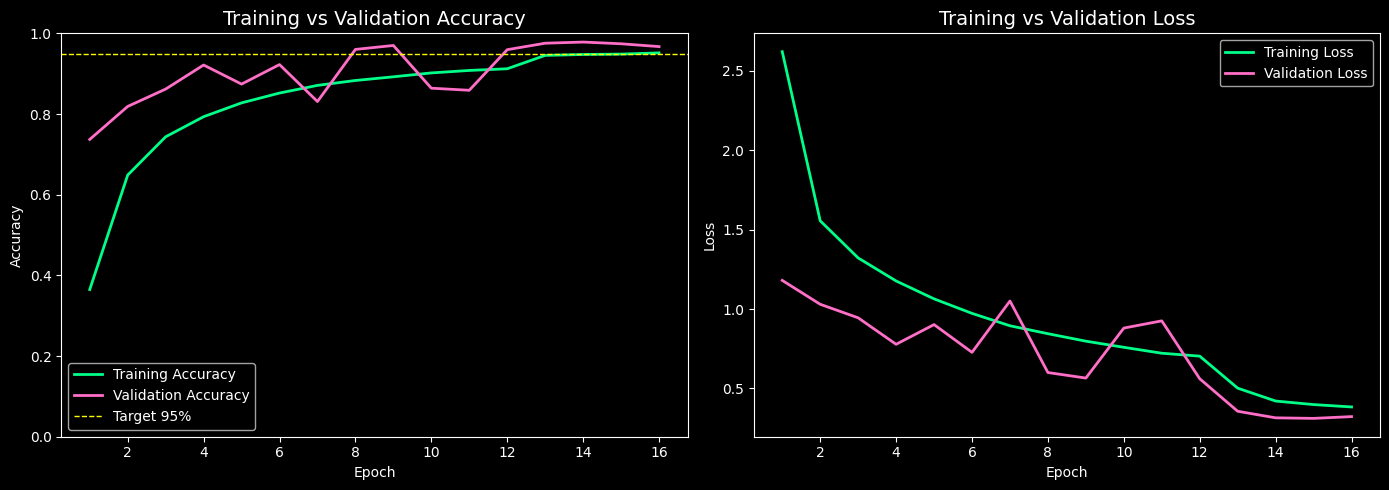

Plot disimpan ke /content/training_plot.png


In [9]:
acc      = history.history['accuracy']
val_acc  = history.history['val_accuracy']
loss     = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot Akurasi ───────────────────────────────────────────────
axes[0].plot(epochs_range, acc,     label='Training Accuracy',   color='#00ff88', linewidth=2)
axes[0].plot(epochs_range, val_acc, label='Validation Accuracy', color='#ff6ec7', linewidth=2)
axes[0].axhline(y=0.95, color='yellow', linestyle='--', linewidth=1, label='Target 95%')
axes[0].set_title('Training vs Validation Accuracy', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].set_ylim([0, 1])

# ── Plot Loss ─────────────────────────────────────────────────
axes[1].plot(epochs_range, loss,     label='Training Loss',   color='#00ff88', linewidth=2)
axes[1].plot(epochs_range, val_loss, label='Validation Loss', color='#ff6ec7', linewidth=2)
axes[1].set_title('Training vs Validation Loss', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('/content/training_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot disimpan ke /content/training_plot.png")

## Konversi Model

In [11]:
# ── A. SavedModel ─────────────────────────────────────────────
saved_model_dir = '/content/saved_model'
tf.saved_model.save(best_model, saved_model_dir)
print(f"✅ SavedModel tersimpan di: {saved_model_dir}")

✅ SavedModel tersimpan di: /content/saved_model


In [12]:
# ── B. TF-Lite ────────────────────────────────────────────────
converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_dir)
converter.optimizations = [tf.lite.Optimize.DEFAULT]  # quantisasi untuk model lebih kecil
tflite_model = converter.convert()

tflite_path = pathlib.Path('/content/model.tflite')
tflite_path.write_bytes(tflite_model)
print(f"✅ TF-Lite tersimpan: {tflite_path} ({tflite_path.stat().st_size / 1024:.1f} KB)")

✅ TF-Lite tersimpan: /content/model.tflite (27.3 KB)


In [13]:
# ── C. TFJS ───────────────────────────────────────────────────
tfjs_dir = '/content/tfjs_model'
!tensorflowjs_converter \
    --input_format=tf_saved_model \
    --output_node_names='StatefulPartitionedCall' \
    {saved_model_dir} \
    {tfjs_dir}

print(f"✅ TFJS model tersimpan di: {tfjs_dir}")
print("File TFJS:")
!ls -lh {tfjs_dir}

2026-06-05 09:15:02.979027: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780650903.003691   40670 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780650903.012560   40670 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780650903.035263   40670 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780650903.035305   40670 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780650903.035316   40670 computation_placer.cc:177] computation placer alr

In [10]:
# Load bobot terbaik (dari checkpoint)
best_model = tf.keras.models.load_model('/content/best_model.keras')

test_loss, test_acc = best_model.evaluate(test_generator, verbose=1)
train_acc_final = max(history.history['accuracy'])
val_acc_final   = max(history.history['val_accuracy'])

print("\n" + "="*45)
print(f"  Akurasi Training  (max) : {train_acc_final*100:.2f}%")
print(f"  Akurasi Validasi  (max) : {val_acc_final*100:.2f}%")
print(f"  Akurasi Test Set        : {test_acc*100:.2f}%")
print("="*45)

if train_acc_final >= 0.95 and test_acc >= 0.95:
    print("✅ Target akurasi 95% TERPENUHI pada Training & Test!")
elif train_acc_final >= 0.85 and test_acc >= 0.85:
    print("✅ Syarat minimum 85% TERPENUHI.")
else:
    print("⚠️ Akurasi belum memenuhi syarat. Pertimbangkan menambah epoch atau fine-tune.")

435/435 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.9804 - loss: 0.3132

  Akurasi Training  (max) : 95.15%
  Akurasi Validasi  (max) : 97.84%
  Akurasi Test Set        : 98.04%
✅ Target akurasi 95% TERPENUHI pada Training & Test!


## Inference

Upload gambar buah untuk diuji...


Saving download (46).jpg to download (46).jpg

File: download (46).jpg


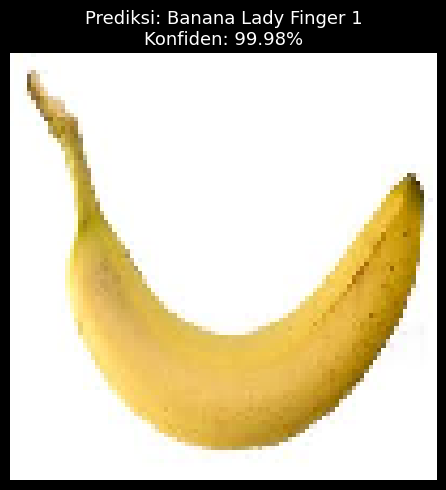


Top-3 Prediksi:
  Banana Lady Finger 1     : 99.98%
  Papaya 2                 : 0.01%
  Banana 1                 : 0.01%

✅ Hasil Prediksi: Banana Lady Finger 1 (99.98%)


In [18]:
# ── Inference dengan SavedModel ───────────────────────────────
class_names = list(train_generator.class_indices.keys())

def predict_image(img_path, mdl, class_names, img_size=(100, 100)):
    """Prediksi satu gambar dan tampilkan hasilnya."""
    img = image.load_img(img_path, target_size=img_size)
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)  # batch dimension

    preds = mdl.predict(img_array, verbose=0)
    pred_idx   = np.argmax(preds[0])
    confidence = preds[0][pred_idx] * 100

    # Top-3 prediksi
    top3_idx  = np.argsort(preds[0])[::-1][:3]
    top3      = [(class_names[i], preds[0][i]*100) for i in top3_idx]

    # Visualisasi
    plt.figure(figsize=(5, 5))
    plt.imshow(image.load_img(img_path, target_size=img_size))
    plt.title(f"Prediksi: {class_names[pred_idx]}\nKonfiden: {confidence:.2f}%",
              fontsize=13, color='white')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    print("\nTop-3 Prediksi:")
    for name, conf in top3:
        print(f"  {name:25s}: {conf:.2f}%")

    return class_names[pred_idx], confidence

# Upload gambar untuk diuji
print("Upload gambar buah untuk diuji...")
uploaded_files = files.upload()

for fn in uploaded_files.keys():
    print(f"\n{'='*40}")
    print(f"File: {fn}")
    pred_class, conf = predict_image(fn, best_model, class_names, IMG_SIZE)
    print(f"\n✅ Hasil Prediksi: {pred_class} ({conf:.2f}%)")